# Step 4: Stress-test Simulation (Resilience Analysis)

This notebook executes the resilience stress-tests on the London Underground network. We compare two progressive station removal scenarios:
- **Scenario A (Random Failure)**: Simulates random outages across the city.
- **Scenario B (Targeted Attack)**: Simulates a coordinated strike targeting the highest-betweenness bottleneck stations.

We track the size of the Largest Connected Component (LCC, connectedness) and the total number of subcomponents (fragmentation) over both scenarios, and visualize the final geographical collapse.

In [1]:
import sys
import os

# Add parent directory to path so we can import src
sys.path.append('..')

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import load_london_network
from src.simulator import run_resilience_simulation

## 1. Run Robustness Simulations

We simulate removing up to 50% of the network's stations and average the random failure results over 50 runs.

In [2]:
G_L, _, _, _ = load_london_network()
fractions, random_lcc, targeted_lcc, random_frag, targeted_frag, random_eff, targeted_eff = run_resilience_simulation(G_L, random_runs=50)

print(f"{'Removal %':<12}{'Rand LCC':<12}{'Target LCC':<12}{'Rand Frag':<12}{'Target Frag':<12}{'Rand Eff':<12}{'Target Eff':<12}")
for i, f in enumerate(fractions):
    print(f"{f*100:<12.1f}{random_lcc[i]:<12.4f}{targeted_lcc[i]:<12.4f}{random_frag[i]:<12.2f}{targeted_frag[i]:<12.2f}{random_eff[i]:<12.4f}{targeted_eff[i]:<12.4f}")

Removal %   Rand LCC    Target LCC  Rand Frag   Target Frag Rand Eff    Target Eff  
0.0         1.0000      1.0000      1.00        1.00        1.0000      1.0000      
5.0         0.8287      0.4073      8.78        12.00       0.8059      0.4197      
10.0        0.6761      0.2417      17.12       26.00       0.6654      0.2623      
15.0        0.4939      0.2351      25.82       35.00       0.5076      0.2266      
20.0        0.3780      0.0960      33.72       44.00       0.4073      0.1549      
25.0        0.2714      0.0563      41.74       46.00       0.3209      0.1455      
30.0        0.1981      0.0530      48.20       48.00       0.2611      0.1417      
35.0        0.1419      0.0331      54.16       49.00       0.2165      0.1385      
40.0        0.1054      0.0331      58.98       49.00       0.1846      0.1382      
45.0        0.0784      0.0331      62.80       47.00       0.1611      0.1435      
50.0        0.0601      0.0298      65.00       48.00       0.145

## 2. Plotting Connectedness, Fragmentation, and Efficiency Decay Curves

We plot the relative decay of the Largest Connected Component (LCC), network fragmentation, and the relative decay of Global Efficiency (representing system-wide passenger routing capacity).

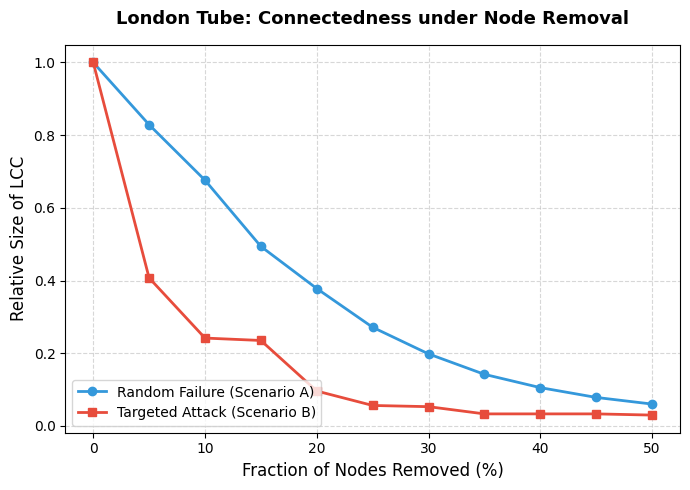

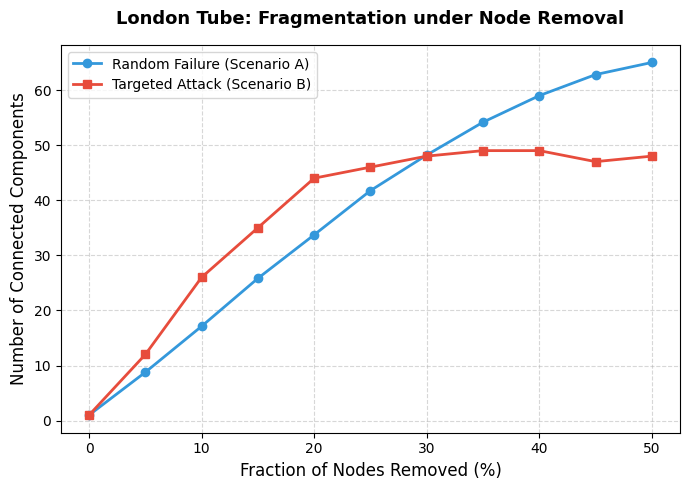

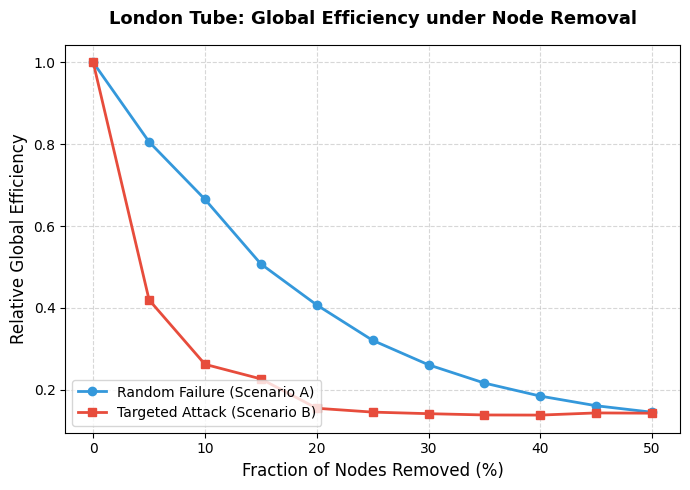

In [3]:
os.makedirs('../latex/figures', exist_ok=True)

# Connectedness LCC Plot
plt.figure(figsize=(7, 5))
plt.plot(fractions * 100, random_lcc, 'o-', color='#3498db', label='Random Failure (Scenario A)', linewidth=2)
plt.plot(fractions * 100, targeted_lcc, 's-', color='#e74c3c', label='Targeted Attack (Scenario B)', linewidth=2)
plt.xlabel('Fraction of Nodes Removed (%)', fontsize=12)
plt.ylabel('Relative Size of LCC', fontsize=12)
plt.title('London Tube: Connectedness under Node Removal', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig('../latex/figures/resilience_lcc.png', dpi=300)
plt.show()

# Fragmentation Plot
plt.figure(figsize=(7, 5))
plt.plot(fractions * 100, random_frag, 'o-', color='#3498db', label='Random Failure (Scenario A)', linewidth=2)
plt.plot(fractions * 100, targeted_frag, 's-', color='#e74c3c', label='Targeted Attack (Scenario B)', linewidth=2)
plt.xlabel('Fraction of Nodes Removed (%)', fontsize=12)
plt.ylabel('Number of Connected Components', fontsize=12)
plt.title('London Tube: Fragmentation under Node Removal', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('../latex/figures/resilience_frag.png', dpi=300)
plt.show()

# Global Efficiency Decay Plot
plt.figure(figsize=(7, 5))
plt.plot(fractions * 100, random_eff, 'o-', color='#3498db', label='Random Failure (Scenario A)', linewidth=2)
plt.plot(fractions * 100, targeted_eff, 's-', color='#e74c3c', label='Targeted Attack (Scenario B)', linewidth=2)
plt.xlabel('Fraction of Nodes Removed (%)', fontsize=12)
plt.ylabel('Relative Global Efficiency', fontsize=12)
plt.title('London Tube: Global Efficiency under Node Removal', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig('../latex/figures/resilience_eff.png', dpi=300)
plt.show()

## 3. Visualizing Network Collapse

We geographically plot the state of the network after a targeted removal of the **top 10 Betweenness Centrality bottlenecks** to inspect physical fragmentation.

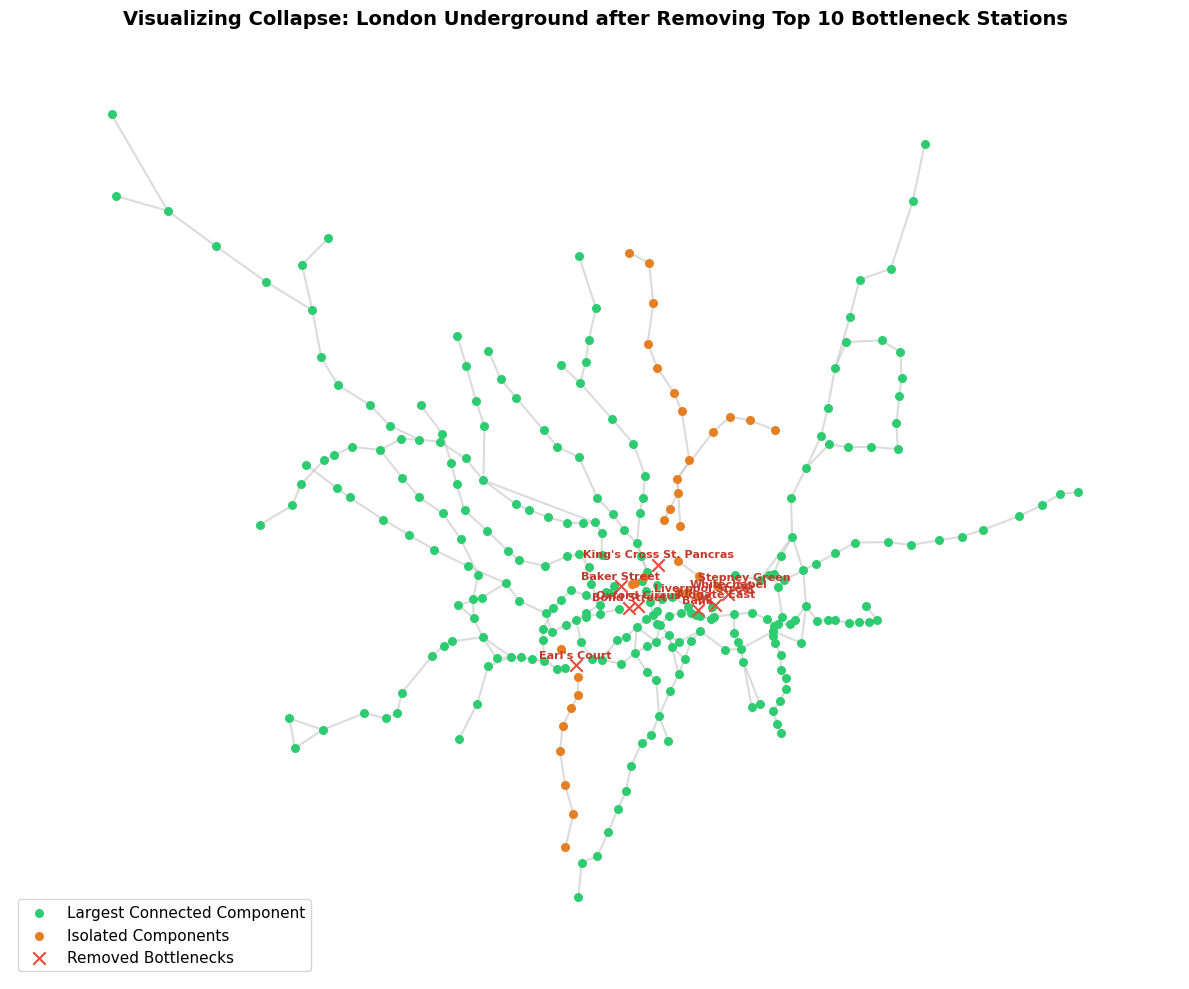

Removed nodes: ['Baker Street', 'Bank', "King's Cross St. Pancras", 'Oxford Circus', 'Whitechapel', 'Aldgate East', 'Bond Street', 'Liverpool Street', "Earl's Court", 'Stepney Green']
LCC Size: 257 nodes (85.10% of original)
Remaining components: 8


In [4]:
G_temp = G_L.copy()
N_tot = len(G_temp.nodes)

# Get original betweenness and top 10 stations
original_bet = nx.betweenness_centrality(G_L, weight='weight')
sorted_nodes = sorted(original_bet.items(), key=lambda x: x[1], reverse=True)
removed_nodes = [node for node, val in sorted_nodes[:10]]

# Remove from copy
G_temp.remove_nodes_from(removed_nodes)

# Find remaining components
components = sorted(list(nx.connected_components(G_temp)), key=len, reverse=True)
lcc_nodes = components[0] if components else set()
pos = {node: (data['lon'], data['lat']) for node, data in G_L.nodes(data=True)}

plt.figure(figsize=(12, 10))
plt.gca().set_facecolor('#f7f9f9')

# Draw intact edges
nx.draw_networkx_edges(G_temp, pos, edge_color='#cccccc', width=1.5, alpha=0.7)

# Draw remaining Largest Connected Component (LCC) in green
nx.draw_networkx_nodes(G_temp, nodelist=list(lcc_nodes), pos=pos, 
                       node_size=30, node_color='#2ecc71', label='Largest Connected Component')

# Draw smaller fragmented components in orange
fragmented_nodes = []
for comp in components[1:]:
    fragmented_nodes.extend(list(comp))
if fragmented_nodes:
    nx.draw_networkx_nodes(G_temp, nodelist=fragmented_nodes, pos=pos, 
                           node_size=30, node_color='#e67e22', label='Isolated Components')

# Draw removed bottlenecks as red crosses
nx.draw_networkx_nodes(G_L, nodelist=removed_nodes, pos=pos, 
                       node_size=80, node_color='#e74c3c', node_shape='x', label='Removed Bottlenecks')

# Label removed stations
removed_pos = {name: (pos[name][0], pos[name][1] + 0.004) for name in removed_nodes}
nx.draw_networkx_labels(G_L, removed_pos, labels={name: name for name in removed_nodes}, 
                        font_color='#c0392b', font_size=8, font_weight='bold')

plt.title("Visualizing Collapse: London Underground after Removing Top 10 Bottleneck Stations", 
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.savefig('../latex/figures/london_tube_collapse.png', dpi=300)
plt.show()

print(f"Removed nodes: {removed_nodes}")
print(f"LCC Size: {len(lcc_nodes)} nodes ({len(lcc_nodes)/N_tot*100:.2f}% of original)")
print(f"Remaining components: {len(components)}")